In this notebook, we present an analysis of our Variational Autoencoder (VAE) method for reconstructing the probability distribution of POVM outcomes for a given quantum state.

We focus on the 4-qubit GHZ state because its larger outcome space ($4^N = 256$ possible outcomes) provides a first meaningful example of an interesting use case for generative modeling via VAEs.

We evaluate the classical fidelity as a function of the number of training samples ($N_{\text{train}}$) used to fit the VAE, benchmarking its denoising performance and identifying the regime of interest where this approach offers a clear advantage over direct empirical distribution.

We deeply analyze the deviation of both the empirical training frequencies ($p_{\text{train}}$) and the reconstructed VAE probability distribution ($p_{\text{gen}}$) from the exact theoretical distribution ($p_{\text{exact}}$). This outcome-level inspection provides crucial insights into the structural behavior of the generative model, moving beyond global metrics like Classical Fidelity.

Finally, we provide a scalability analysis up to an 8-qubit system. As an illustrative example, we briefly demonstrate how the VAE framework successfully scales to higher-dimensional Hilbert spaces by evaluating the classical fidelity against the number of training samples for systems up to $N=8$ qubits ($4^8 = 65,536$ outcomes).

#### Colab setup

In [ ]:
# --- drive mount to access the shared drive repo ---
# (only for using colab GPUs)
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# lib src folder
import sys
sys.path.append('/content/drive/MyDrive/statistical-qst-vae/statistical-qst-vae/src')

# Import

In [1]:
# general import:
import sys
import time
import os
import gc
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# quantum import:
from qiskit import QuantumCircuit
from qiskit.quantum_info import DensityMatrix
from qiskit.visualization import plot_state_city, plot_state_hinton, plot_state_qsphere

In [3]:
# ML import:
import tensorflow as tf
import keras
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import sklearn
from sklearn.model_selection import train_test_split

In [4]:
# custom helper and libraries:
sys.path.append('../src')
from povm_sampling import *
from statesprep import *
from vae import *
from plots import *
from utils import *
from mle import *

In [5]:
# repo directory
PROJECT_DIR = Path.cwd().parent   

# figs directory
FIGS_DIR = PROJECT_DIR / 'figs'
FIGS_DIR.mkdir(parents=True, exist_ok=True)

# MLE data directory
DATA_DIR = PROJECT_DIR / 'data' / 'VAE_analysis'
DATA_DIR.mkdir(parents=True, exist_ok=True)

# State GHZ4

GHZ state for a 4-qubit system: $\space \frac{1}{\sqrt{2}}(\ket{0000} + \ket{1111})$

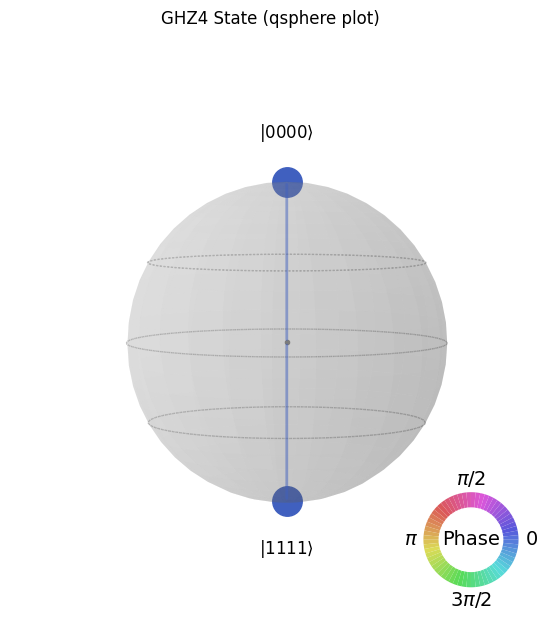

In [6]:
# true state GHZ4
N = 4
qc = create_ghz_state(N)
rho = DensityMatrix(qc)

# plot
fig = plot_state_qsphere(rho)
fig.suptitle('GHZ4 State (qsphere plot)')
display(fig)

In [7]:
# exact distribution and possible outcomes
p_exact = povm_probability_efficient(rho.data, N)
outcomes = list(p_exact.keys())  
print('N of possible outcomes: ', len(outcomes))

N of possible outcomes:  256


## $F_c \space$ VAE and empirical dist. vs $N_{\text{train}}$

#### data sampling

In [7]:
# --- VAE config for N=4 qubit system ---

LATENT_DIM = 32         # latent space dim
HIDDEN_DIM = 128        # number of neurons in the hidden layers (both encoder/decoder)
WARMUP_EPOCHS = 40      # epochs for KL weight annealing strategy
TOTAL_EPOCHS = 500
BATCH_SIZE = 200
LEARNING_RATE = 1e-3
BETA_MAX = 0.85         # max value for the KL weight
N_GEN = 100000          # number of generated samples to estimate the VAE prob.

We consider $B=20$ independent runs to evaluate a naive statistics of $F_c$.

In [ ]:
B = 20      # number of independent experiments/runs to construct Fc distributions
N_SAMPLES = [300, 500, 1000, 2000, 5000, 10000]

runs = []
for i in range(B):
    # prepare run dictionary
    results = {"n_samples": [], "Fc": [], "Fc_train": []}

    for n_samples in N_SAMPLES:
        print(f"\n=== N_QUBITS={N}   N_SAMPLES={n_samples} ===")

        seed = 1234 + i + n_samples
        # sampling the exact probability and creating train set
        sample = sample_povm(p_exact, n_samples=n_samples, seed=seed)
        onehot_sample = samples_to_onehot(sample, N)
        X_train, X_test = train_test_split(onehot_sample, test_size=0.2, random_state=42)

        # model building and definition
        vae = VAE(n_qubits=N, latent_dim=LATENT_DIM, hidden=HIDDEN_DIM)
        vae.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE))
        vae.build(input_shape=(None, 4*N))  

        callbacks = [
            KLWarmup(beta_max=BETA_MAX, warmup_epochs=WARMUP_EPOCHS),
            EarlyStopping(monitor='reconstruction_loss', mode='min',
                            patience=40, restore_best_weights=True, start_from_epoch=WARMUP_EPOCHS),
        ]

        history = vae.fit(
            X_train, X_train,
            epochs=TOTAL_EPOCHS,
            batch_size=BATCH_SIZE,
            validation_data=(X_test, X_test),
            callbacks=callbacks,
            verbose=0,
        )

        # reconstruct VAE probability and compute metrics
        P_vae   = vae.predict_dist(n_samples=N_GEN, batch_size=50_000)
        P_train = samples_to_empirical_dist(onehot_to_samples(X_train, N), N)

        Fc        = classical_fidelity(P_vae,   p_exact)
        Fc_train  = classical_fidelity(P_train, p_exact)

        # print with minimal informations
        print(f"  Fidelity classica VAE vs esatta : {Fc:.4f}   <- MODELLO")
        print(f"  Fidelity classica training vs esatta : {Fc_train:.4f}   <- TETTO")

        # log metrics
        results["n_samples"].append(n_samples)
        results["Fc"].append(Fc)
        results["Fc_train"].append(Fc_train)     

    print("\nRESULTS:", results)

    # single run df, adding 'run' value
    results_df = pd.DataFrame(results)
    results_df["run"] = i + 1  
    runs.append(results_df)


=== N_QUBITS=4   N_SAMPLES=300 ===
All saved in: /Users/riccardoruggeri/project-sda/statistical-qst-vae/results/vae_analysis/run_1/vae_training_q4_n300_0616_1129
  Fidelity classica VAE vs esatta : 0.9562   <- MODELLO
  Fidelity classica training vs esatta : 0.8371   <- TETTO

=== N_QUBITS=4   N_SAMPLES=500 ===
All saved in: /Users/riccardoruggeri/project-sda/statistical-qst-vae/results/vae_analysis/run_1/vae_training_q4_n500_0616_1129
  Fidelity classica VAE vs esatta : 0.9715   <- MODELLO
  Fidelity classica training vs esatta : 0.8854   <- TETTO

=== N_QUBITS=4   N_SAMPLES=1000 ===
All saved in: /Users/riccardoruggeri/project-sda/statistical-qst-vae/results/vae_analysis/run_1/vae_training_q4_n1000_0616_1129
  Fidelity classica VAE vs esatta : 0.9653   <- MODELLO
  Fidelity classica training vs esatta : 0.9487   <- TETTO

=== N_QUBITS=4   N_SAMPLES=2000 ===
All saved in: /Users/riccardoruggeri/project-sda/statistical-qst-vae/results/vae_analysis/run_1/vae_training_q4_n2000_0616_1129

In [ ]:
# saving final results into unique df
df = pd.concat(runs, ignore_index=True)
df.to_csv(DATA_DIR / 'VAE_results_advantage_allN_B20.csv', index=False)
print("\n Saved!\t N_rows:", len(df))


 Saved!	 N_rows: 120


#### plot

Loaded! N_rows: 120


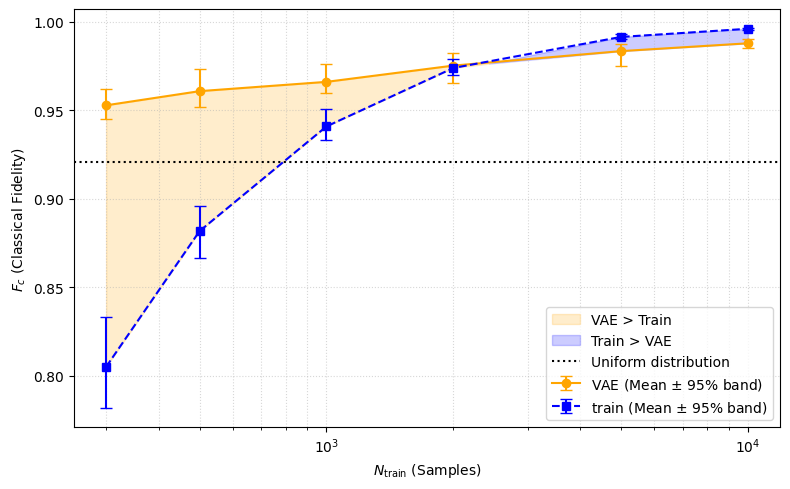

In [11]:
# --- load ---
csv_path = DATA_DIR / 'VAE_results_advantage_allN_B20.csv'
df = pd.read_csv(csv_path)

print(f"Loaded! N_rows: {len(df)}")

# -- statistical processing --
P_unif = {o: 1.0 / len(outcomes) for o in outcomes}

# sort and extract n_sample values
df_sorted = df.sort_values("n_samples")
n_values = sorted(df_sorted.n_samples.unique())

# grouping for n_sample
g_fc = df_sorted.groupby("n_samples")["Fc"]
g_fc_train = df_sorted.groupby("n_samples")["Fc_train"]

# mean values
fc_mean = g_fc.mean().values
fc_train_mean = g_fc_train.mean().values

# errorbar considering +- 95% band: 
# (lower bound, upper bound) = ([mean - q_0.025], [q_0.975 - mean])

fc_err_below = fc_mean - g_fc.quantile(0.025).values
fc_err_above = g_fc.quantile(0.975).values - fc_mean
yerr_fc = np.vstack([fc_err_below, fc_err_above])

fc_train_err_below = fc_train_mean - g_fc_train.quantile(0.025).values
fc_train_err_above = g_fc_train.quantile(0.975).values - fc_train_mean
yerr_fc_train = np.vstack([fc_train_err_below, fc_train_err_above])

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 5))

# errorbars
ax.errorbar(n_values, fc_mean, yerr=yerr_fc,
             fmt='-o', color='orange', capsize=4, label=r'VAE (Mean $\pm$ 95% band)')

ax.errorbar(n_values, fc_train_mean, yerr=yerr_fc_train,
             fmt='--s', color='blue', capsize=4, label=r'train (Mean $\pm$ 95% band)')

# fill between: train classical fidelity and VAE classical fidelity
# orange fill when VAE fidelity is higher than train fidelity, blue fill otherwise
ax.fill_between(n_values, fc_mean, fc_train_mean,
                 where=(fc_mean >= fc_train_mean),
                 interpolate=True, color='orange', alpha=0.2, label='VAE > Train')

ax.fill_between(n_values, fc_mean, fc_train_mean,
                 where=(fc_mean < fc_train_mean),
                 interpolate=True, color='blue', alpha=0.2, label='Train > VAE')

# --- plot config ---
ax.axhline(y=classical_fidelity(P_unif, p_exact), color='black', linestyle=':', label='Uniform distribution')
ax.set_xscale('log')
ax.set_xlabel('$N_{\\text{train}}$ (Samples)')
ax.set_ylabel('$F_c$ (Classical Fidelity)')
ax.grid(True, which='both', ls=':', alpha=0.5)
ax.legend()

fig.tight_layout()

# -- title --
# plt.title(f'Classical Fidelity vs Training Samples\nState: GHZ 4-qubit')

# -- save fig --
fig.savefig(FIGS_DIR / 'VAE_ghz4_fidelity.svg', bbox_inches='tight')

plt.show()

This plot shows where is the interest interval in number of samples that makes VAE an interesting methods for denoising, reducing the necessary expensive sample measurements.

## Deviation from $p_{\text{exact}}$

Here we fixed $N_{\text{sample}}=1000$ and train a VAE model to deeply evaluate the performance in probability reconstruction of each single outcome.

#### data sampling

In [14]:
# true state GHZ4
N = 4
qc = create_ghz_state(N)
rho = DensityMatrix(qc)

# sample the true probability distribution
n_samples = 1000
p_exact = povm_probability_efficient(rho.data, N)
samples = sample_povm(p_exact, n_samples=n_samples)

# onehot encoding and split into training and testing sets 
onehot_samples = samples_to_onehot(samples, N)
X_train, X_test = train_test_split(onehot_samples, test_size=0.2, random_state=42)
print(f"Training set size and shape: {len(X_train)} and {X_train.shape}")
print(f"Testing set size and shape: {len(X_test)} and {X_test.shape}")

Training set size and shape: 800 and (800, 16)
Testing set size and shape: 200 and (200, 16)


In [15]:
# --- VAE config for N=4 qubit system ---
LATENT_DIM = 32         # latent space dim
HIDDEN_DIM = 128        # number of neurons in the hidden layers (both encoder/decoder)
WARMUP_EPOCHS = 40      # epochs for KL weight annealing strategy
TOTAL_EPOCHS = 500
BATCH_SIZE = 200
LEARNING_RATE = 1e-3
BETA_MAX = 0.85         # max value for the KL weight
N_GEN = 100000          # number of generated samples to estimate the VAE prob.

In [17]:
# create and compile the VAE model
vae = VAE(n_qubits=N, latent_dim=LATENT_DIM, hidden=HIDDEN_DIM)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE))
vae.build(input_shape=(None, 4*N))

In [18]:
# fit:

# Define callbacks for training
callbacks = [
    KLWarmup(beta_max=BETA_MAX, warmup_epochs=WARMUP_EPOCHS),
    EarlyStopping(monitor='loss', mode='min',
                  patience=50, restore_best_weights=True, 
                  start_from_epoch=WARMUP_EPOCHS),
    ReduceLROnPlateau(monitor='loss', mode='min',          # keras callback to reduce LR in the final steps of training
                      factor=0.5, patience=20, min_lr=1e-6),
]

# fit data
history = vae.fit(
    X_train, X_train,
    epochs=TOTAL_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, X_test),
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - kl_loss: 0.6253 - kl_weight: 0.0213 - loss: 5.7669 - reconstruction_loss: 5.7536 - val_kl_loss: 0.6348 - val_loss: 5.6225 - val_reconstruction_loss: 5.6090 - learning_rate: 0.0010
Epoch 2/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - kl_loss: 0.6864 - kl_weight: 0.0425 - loss: 5.4990 - reconstruction_loss: 5.4698 - val_kl_loss: 0.7017 - val_loss: 5.4864 - val_reconstruction_loss: 5.4566 - learning_rate: 0.0010
Epoch 3/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - kl_loss: 0.8342 - kl_weight: 0.0637 - loss: 5.4048 - reconstruction_loss: 5.3516 - val_kl_loss: 0.8324 - val_loss: 5.4402 - val_reconstruction_loss: 5.3872 - learning_rate: 0.0010
Epoch 4/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - kl_loss: 1.0162 - kl_weight: 0.0850 - loss: 5.3614 - reconstruction_loss: 5.2750 - val_kl_loss: 1.0183 - val_loss: 5.3583 - val_reconstruction_loss: 5.2717 - learning_rate: 0.0010
Epoch 5/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - kl_loss: 1.2816 - kl

In [ ]:
# save history:
pd.DataFrame(history.history).to_csv(DATA_DIR / 'history_deviation.csv', index=False)

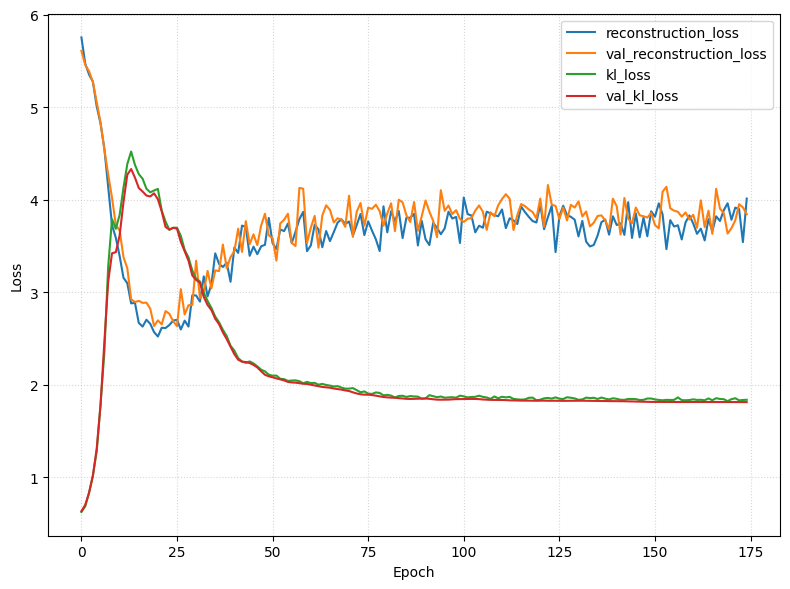

In [8]:
# plot the training and validation loss curves
loaded_history = pd.read_csv(DATA_DIR /'history_deviation.csv')
fig = plot_reconstruction_and_kl_divergence(loaded_history, title=False);
fig.savefig(FIGS_DIR / 'VAE_ghz4_loss.svg', bbox_inches='tight')

In [34]:
# classical fidelity analysis and comparison

outcomes = list(p_exact.keys())

# Generate a large number of samples from the trained VAE model to estimate the distribution it has learned (p_vae)
# Convert the one-hot encoded training data back to samples and compute the empirical distribution (p_train)
p_vae   = vae.predict_dist(n_samples=N_GEN, batch_size=50_000)
p_unif = {o: 1.0 / len(outcomes) for o in outcomes}
p_train = samples_to_empirical_dist(onehot_to_samples(X_train, N), N)   # N_train are less then total N_samples

# Compute the classical fidelity between the distributions
classical_fidelity_floor = classical_fidelity(p_unif, p_exact)
classical_fidelity_vae = classical_fidelity(p_vae, p_exact)
classical_fidelity_train = classical_fidelity(p_train, p_exact)

print("=== Classical Fidelity ===")
print(f"  uniform          vs true : {classical_fidelity_floor:.4f}   <- FLOOR")
print(f"  VAE              vs true : {classical_fidelity_vae:.4f}   <- MODEL")
print(f"  training data    vs true : {classical_fidelity_train:.4f}   <- BASELINE\n")

=== Classical Fidelity ===
  uniform          vs true : 0.9209   <- FLOOR
  VAE              vs true : 0.9625   <- MODEL
  training data    vs true : 0.9394   <- BASELINE



In [ ]:
# -- save distributions --
prob_df = pd.DataFrame({
    'outcome': outcomes,
    'p_exact': [p_exact.get(o, 0.0) for o in outcomes],
    'p_vae':   [p_vae.get(o, 0.0) for o in outcomes],
    'p_train': [p_train.get(o, 0.0) for o in outcomes],
    'p_unif':  [p_unif.get(o, 0.0) for o in outcomes]
})

prob_df.to_csv(DATA_DIR / 'probabilities_comparison.csv', index=False)

print('Saved!')

Saved!


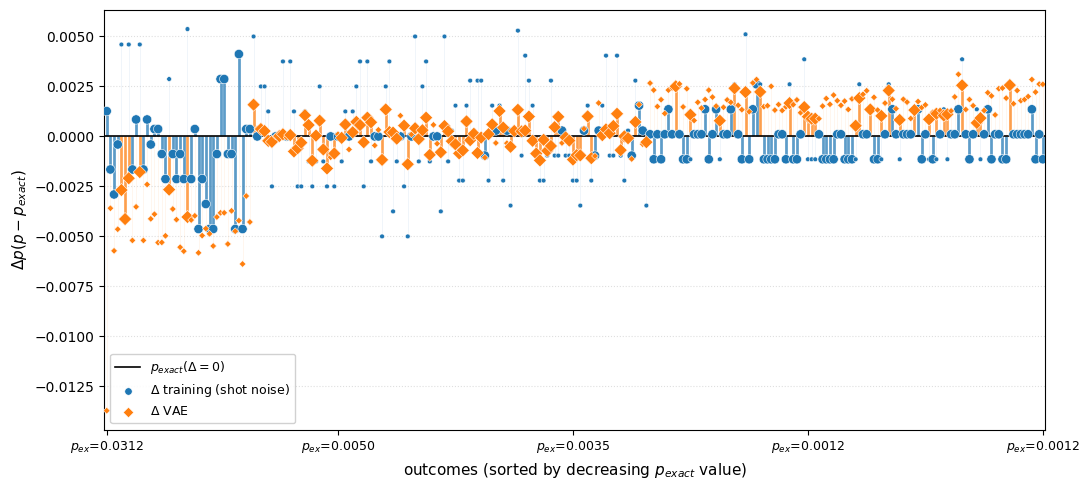

In [13]:
# -- load --
df_loaded = pd.read_csv(DATA_DIR / 'probabilities_comparison.csv')

outcomes = df_loaded['outcome'].tolist()
p_true = df_loaded['p_exact'].to_numpy()
p_gen  = df_loaded['p_vae'].to_numpy()
p_emp  = df_loaded['p_train'].to_numpy()

# -- plot the deviation in distributions (p_exact vs p_vae, p_train) over the outcomes --
fig = plot_distribution_delta(p_true, p_gen, p_emp, abs=False, highlight_markers=True, highlight_lines=True, title=False)

# -- save fig --
fig.savefig(FIGS_DIR / 'VAE_ghz4_deviation.svg', bbox_inches='tight')


The minor deviation between *empirical frequencies of sample training* and *reconstructed probability of VAE* compared to the exact probability are highlighted with markers and vertical lines. The outcomes are sorted by decreasing value of amplitude.

We can easily see the tendency of the VAE to underestimate high-probability outcomes and overestimate lower-probability ones. This behavior is highly coherent with a model that starts with no prior knowledge (acting effectively as a uniform generator) and gradually adapts to the distribution suggested by the training data.

The VAE's loss function forces the network to strike a balance between memorizing the training samples (reconstruction loss) and aligning its latent space with an agnostic prior: as a result, when the model adapts to the probabilities suggested by the training data, the regularizer acts as a smoothing constraint. It pulls the sharpest peaks downwards and fills in the undersampled tails, preventing the network from overfitting to the empirical shot noise.

# Scalability analysis

#### data sampling

In [ ]:
N_SAMPLES = [5000, 10000, 20000, 50000]
N_QUBITS = [4, 6, 8]

# -- fixed VAE config --
WARMUP_EPOCHS = 40      # epochs for KL weight annealing strategy
TOTAL_EPOCHS = 500
LEARNING_RATE = 1e-3
BETA_MAX = 0.85         # max value for the KL weight

# -- config dict --
CFG = {
    4: dict(latent_dim=32,  hidden=128,  batch_size=200, N_GEN=100000),
    6: dict(latent_dim=256, hidden=1280, batch_size=600, N_GEN=4**6 * 500),
    8: dict(latent_dim=512, hidden=2560, batch_size=1000, N_GEN=4**7 * 500),
}

# log dictionary 
results = {q: {"n_samples": [], "Fc": [], "Fc_train": []} for q in N_QUBITS}

for q in N_QUBITS:

    # true state, exact probability and possible outcomes
    qc = create_ghz_state(q)
    rho = DensityMatrix(qc)
    P_exact = povm_probability_efficient(rho.data, q)
    outcomes = list(P_exact.keys())

    for n_samples in N_SAMPLES:
        print(f"\n=== N_QUBITS={q}   N_SAMPLES={n_samples} ===")


        seed = 1234 + n_samples + q
        # data sampling and train set
        sample = sample_povm(P_exact, n_samples=n_samples, seed=seed)
        onehot_sample = samples_to_onehot(sample, q)
        X_train, X_test = train_test_split(onehot_sample, test_size=0.2, random_state=42)

        # model building, according to CFG dict
        cfg = CFG[q]
        latent_dim, hidden, batch_size, n_gen = cfg["latent_dim"], cfg["hidden"], cfg["batch_size"], cfg["N_GEN"]

        vae = VAE(n_qubits=q, latent_dim=latent_dim, hidden=hidden)
        vae.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE))
        vae.build(input_shape=(None, 4 * q))

        callbacks = [
            KLWarmup(beta_max=BETA_MAX, warmup_epochs=WARMUP_EPOCHS),
            EarlyStopping(monitor='reconstruction_loss', mode='min',
                            patience=40, restore_best_weights=True, start_from_epoch=WARMUP_EPOCHS),
        ]

        history = vae.fit(
            X_train, X_train,
            epochs=TOTAL_EPOCHS,
            batch_size=batch_size,
            validation_data=(X_test, X_test),
            callbacks=callbacks,
            verbose=0,
        )

        # reconstruct VAE probability and compute metrics
        P_vae   = vae.predict_dist(n_samples=n_gen, batch_size=50_000)
        P_train = samples_to_empirical_dist(onehot_to_samples(X_train, q), q)

        Fc        = classical_fidelity(P_vae,   P_exact)
        Fc_train  = classical_fidelity(P_train, P_exact)

        # print with minimal informations
        print(f"  Classical Fidelity VAE vs exact: {Fc:.4f}   <- MODEL")
        print(f"  Classical Fidelity training vs exact: {Fc_train:.4f}   <- BASELINE")

        # log run results
        results[q]["n_samples"].append(n_samples)
        results[q]["Fc"].append(Fc)
        results[q]["Fc_train"].append(Fc_train)

    print("\nRESULTS:", results)

# save results to a CSV file for later analysis and plotting
results_df = pd.DataFrame({
    "n_qubits": np.repeat(N_QUBITS, len(N_SAMPLES)),
    "n_samples": np.tile(N_SAMPLES, len(N_QUBITS)),
    "Fc": [results[q]["Fc"][i] for q in N_QUBITS for i in range(len(N_SAMPLES))],
    "Fc_train": [results[q]["Fc_train"][i] for q in N_QUBITS for i in range(len(N_SAMPLES))],
})

# Save the results to a CSV file for later analysis and plotting PROJECT_ROOT
results_df.to_csv(DATA_DIR / "VAE_resutlts_scalability_allN_B1.csv", index=False)


=== N_QUBITS=4   N_SAMPLES=5000 ===
All saved in: /content/drive/MyDrive/statistical-qst-vae/statistical-qst-vae/results/scalability_vae_analysis/run_q4_n5000/vae_training_q4_n5000_0616_1510
  Classical Fidelity VAE vs exact: 0.9847   <- MODEL
  Classical Fidelity training vs exact: 0.9894   <- BASELINE

=== N_QUBITS=4   N_SAMPLES=10000 ===
All saved in: /content/drive/MyDrive/statistical-qst-vae/statistical-qst-vae/results/scalability_vae_analysis/run_q4_n10000/vae_training_q4_n10000_0616_1511
  Classical Fidelity VAE vs exact: 0.9888   <- MODEL
  Classical Fidelity training vs exact: 0.9957   <- BASELINE

=== N_QUBITS=4   N_SAMPLES=20000 ===
All saved in: /content/drive/MyDrive/statistical-qst-vae/statistical-qst-vae/results/scalability_vae_analysis/run_q4_n20000/vae_training_q4_n20000_0616_1512
  Classical Fidelity VAE vs exact: 0.9896   <- MODEL
  Classical Fidelity training vs exact: 0.9981   <- BASELINE

=== N_QUBITS=4   N_SAMPLES=50000 ===
All saved in: /content/drive/MyDrive/s

#### plots

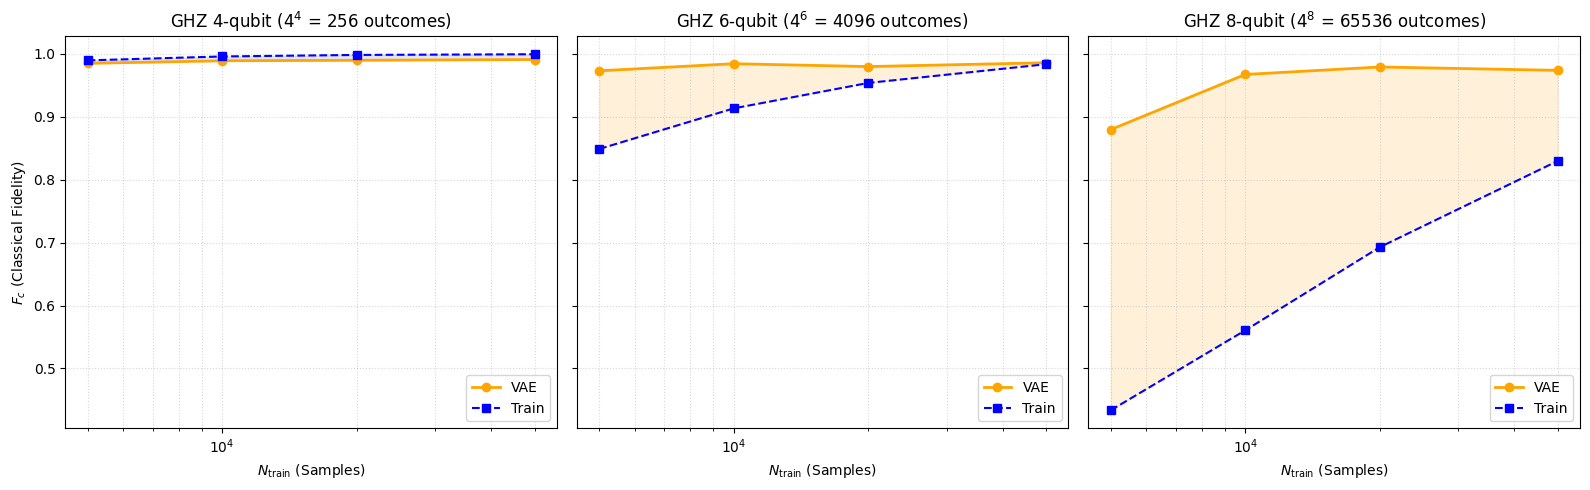

In [14]:
# --- load data ---
csv_path = DATA_DIR / 'VAE_resutlts_scalability_allN_B1.csv'
df = pd.read_csv(csv_path)

qubit_list = sorted(df['n_qubits'].unique())
n_values = sorted(df['n_samples'].unique())

# --- plots ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for idx, q in enumerate(qubit_list):
    ax = axes[idx]
    df_q = df[df['n_qubits'] == q].sort_values("n_samples")
    
    fc_vae = df_q['Fc'].values
    fc_train = df_q['Fc_train'].values
    
    # Fc lines
    ax.plot(n_values, fc_vae, '-o', color='orange', linewidth=2, label='VAE')
    ax.plot(n_values, fc_train, '--s', color='blue', linewidth=1.5, label='Train')
    
    # fill 
    ax.fill_between(n_values, fc_vae, fc_train, where=(fc_vae >= fc_train),
                    interpolate=True, color='orange', alpha=0.15)
    ax.fill_between(n_values, fc_vae, fc_train, where=(fc_vae < fc_train),
                    interpolate=True, color='blue', alpha=0.1)
    
    # -- single plot config --
    ax.set_xscale('log')
    ax.set_xlabel('$N_{\\text{train}}$ (Samples)')
    ax.set_title(f'GHZ {q}-qubit ($4^{q}$ = {4**q} outcomes)')
    ax.grid(True, which='both', ls=':', alpha=0.5)
    ax.legend(loc='lower right')

# -- global config and title --
axes[0].set_ylabel('$F_c$ (Classical Fidelity)')
# plt.suptitle('Scalability Analysis: Classical Fidelity vs Training Samples\nGHZ State ($N = 4, 6, 8$)', fontsize=14, y=1.02)

fig.tight_layout()

# -- save fig --
fig.savefig(FIGS_DIR / 'VAE_scalability.svg', bbox_inches='tight')

plt.show()

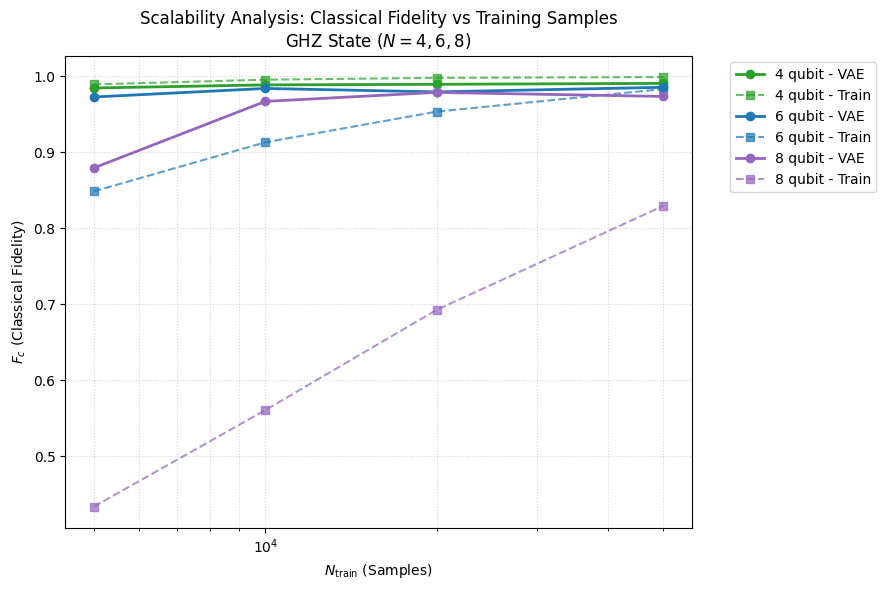

In [22]:
# -- load --
csv_path = DATA_DIR / 'VAE_resutlts_scalability_allN_B1.csv'
df = pd.read_csv(csv_path)

qubit_list = sorted(df['n_qubits'].unique())
n_values = sorted(df['n_samples'].unique())

# colors
qubit_colors = {
    4: '#2ca02c',  # Verde
    6: '#1f77b4',  # Blu
    8: '#9467bd'   # Viola
}

# -- plot --
fig, ax = plt.subplots(figsize=(9, 6))

for q in qubit_list:
    df_q = df[df['n_qubits'] == q].sort_values("n_samples")
    
    fc_vae = df_q['Fc'].values
    fc_train = df_q['Fc_train'].values
    color = qubit_colors[q]
    
    # main lines
    ax.plot(n_values, fc_vae, '-o', color=color, linewidth=2, 
             label=f'{q} qubit - VAE')
    ax.plot(n_values, fc_train, '--s', color=color, linewidth=1.5, alpha=0.7, 
             label=f'{q} qubit - Train')
    
    # fill
    # ax.fill_between(n_values, fc_vae, fc_train, color=color, alpha=0.12)

# -- plot config --
ax.set_xscale('log')
ax.set_xlabel('$N_{\\text{train}}$ (Samples)')
ax.set_ylabel('$F_c$ (Classical Fidelity)')
ax.grid(True, which='both', ls=':', alpha=0.5)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# -- title --
ax.set_title('Scalability Analysis: Classical Fidelity vs Training Samples\nGHZ State ($N = 4, 6, 8$)')

fig.tight_layout()

# -- save fig --
# fig.savefig(FIGS_DIR / 'MLE_convergence_fidelities.svg', bbox_inches='tight')

plt.show()

NB: We provide a simple example to illustrate the real potential of this approach when applied to higher-dimensional spaces. Due to the exponential scaling of quantum state simulations, tracking the exact probability distributions via the Born Rule requires expensive algebraic computations involving non-trivial, large-scale matrices.

This computational bottleneck strictly limited our analysis to a maximum of 8 qubits and prevented us from executing multiple independent runs to calculate statistical uncertainty bands. Consequently, this scalability analysis serves as a deterministic, intuitive demonstration to showcase the scaling trends and the concrete potential of the generative model in regimes where empirical data becomes critically sparse.